# Analysis in logistics

**Goal:**
To improve operational efficiency and reduce costs in the logistics network.

**Task:**

- To identify the main causes of delivery delays.
- To analyze route profitability and highlight underperforming routes.
- To evaluate driver performance and identify top and low performers.
- To identify the key factors driving high fuel costs.
- To identify drivers who are both high-cost and high-risk.

Dataset

**Source:** [Logistics Operations Database – Kaggle](https://www.kaggle.com/datasets/yogape/logistics-operations-database)

14 relational tables | ~85,000 trips | 2022–2023 data

| Table | Rows | Description |
|---|---|---|
| `trips` | 85,411 | Core trip records with fuel, distance, duration |
| `loads` | 85,411 | Shipment details, revenue, customer |
| `delivery_events` | 170,821 | Pickup/delivery timestamps, on-time flags |
| `fuel_purchases` | 196,443 | Fuel transactions by trip and driver |
| `drivers` | 150 | Driver profiles, experience, CDL class |
| `trucks` | 120 | Fleet inventory, make, model year |
| `maintenance_records` | 2,920 | Service history, downtime, costs |
| `safety_incidents` | 170 | Accidents, violations, damage costs |
| `routes` | 58 | Origin–destination lanes, base rates |
| `customers` | 200 | Accounts, contract types, revenue potential |

##  Installing and Setup

In [153]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##  Data Loading

In [154]:
trips = pd.read_csv('../data/trips.csv')
loads = pd.read_csv('../data/loads.csv')
routes = pd.read_csv('../data/routes.csv')
delivery_events = pd.read_csv('../data/delivery_events.csv')
driver_monthly_metrics = pd.read_csv('../data/driver_monthly_metrics.csv')
safety_incidents = pd.read_csv('../data/safety_incidents.csv')

## Data Overview

### Trips 

In [155]:
trips.head(5)


,trip_id,load_id,driver_id,truck_id,trailer_id,dispatch_date,actual_distance_miles,actual_duration_hours,fuel_gallons_used,average_mpg,idle_time_hours,trip_status
0,TRIP00000001,LOAD00000001,DRV00117,TRK00035,TRL00167,2022-01-01,1314,26.20,183.80,7.15,3.50,Completed
1,TRIP00000002,LOAD00000002,DRV00141,TRK00108,TRL00082,2022-01-01,515,8.60,93.60,5.50,8.30,Completed
2,TRIP00000003,LOAD00000003,DRV00032,TRK00031,TRL00138,2022-01-01,2509,45.00,339.10,7.40,12.00,Completed
3,TRIP00000004,LOAD00000004,DRV00083,TRK00105,TRL00018,2022-01-01,717,11.10,110.30,6.50,9.60,Completed
4,TRIP00000005,LOAD00000005,DRV00044,TRK00076,TRL00054,2022-01-01,2243,35.00,328.90,6.82,11.60,Completed


In [156]:
trips.describe()

,actual_distance_miles,actual_duration_hours,fuel_gallons_used,average_mpg,idle_time_hours
count,"85,410.00","85,410.00","85,410.00","85,410.00","85,410.00"
mean,"1,430.27",25.01,221.83,6.50,7.01
std,801.93,14.19,126.56,0.58,2.88
min,90.00,1.40,12.00,5.50,2.00
25%,717.00,12.60,111.80,6.00,4.50
50%,"1,297.50",23.00,204.50,6.50,7.00
75%,"2,147.00",36.90,326.40,7.00,9.50
max,"3,391.00",67.80,611.90,7.50,12.00


In [157]:
trips.isnull().sum()

trip_id                     0
load_id                     0
driver_id                1714
truck_id                 1672
trailer_id               1680
dispatch_date               0
actual_distance_miles       0
actual_duration_hours       0
fuel_gallons_used           0
average_mpg                 0
idle_time_hours             0
trip_status                 0
dtype: int64

~2% trips have missing driver_id, truck_id, trailer_id. 
Likely unassigned trips at time of dispatch. Will keep rows 
but flag for context in driver/fleet analysis.

In [158]:
trips.duplicated().sum()

np.int64(0)

In [159]:
trips['dispatch_date'] = pd.to_datetime(trips['dispatch_date'])

In [160]:
trips.info()

<class 'pandas.DataFrame'>
RangeIndex: 85410 entries, 0 to 85409
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   trip_id                85410 non-null  str           
 1   load_id                85410 non-null  str           
 2   driver_id              83696 non-null  str           
 3   truck_id               83738 non-null  str           
 4   trailer_id             83730 non-null  str           
 5   dispatch_date          85410 non-null  datetime64[us]
 6   actual_distance_miles  85410 non-null  int64         
 7   actual_duration_hours  85410 non-null  float64       
 8   fuel_gallons_used      85410 non-null  float64       
 9   average_mpg            85410 non-null  float64       
 10  idle_time_hours        85410 non-null  float64       
 11  trip_status            85410 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(6)
memory usage: 7.8 MB

### Loads

In [161]:
loads.head(10)

,load_id,customer_id,route_id,load_date,load_type,weight_lbs,pieces,revenue,fuel_surcharge,accessorial_charges,load_status,booking_type
0,LOAD00000001,CUST00183,RTE00019,2022-01-01,Dry Van,19178,13,"3,045.23",406.72,100,Completed,Spot
1,LOAD00000002,CUST00076,RTE00058,2022-01-01,Dry Van,27761,22,"1,224.48",98.61,0,Completed,Dedicated
2,LOAD00000003,CUST00027,RTE00048,2022-01-01,Refrigerated,35594,16,"7,171.12",792.88,0,Completed,Spot
3,LOAD00000004,CUST00088,RTE00013,2022-01-01,Refrigerated,33274,10,"1,308.20",141.33,50,Completed,Spot
4,LOAD00000005,CUST00185,RTE00020,2022-01-01,Dry Van,40257,10,"3,317.18",738.48,0,Completed,Spot
5,LOAD00000006,CUST00193,RTE00004,2022-01-01,Refrigerated,34671,10,"3,582.78",383.23,75,Completed,Spot
6,LOAD00000007,CUST00169,RTE00038,2022-01-01,Dry Van,14530,4,"3,872.46",314.64,150,Completed,Contract
7,LOAD00000008,CUST00049,RTE00016,2022-01-01,Refrigerated,16927,26,"5,914.90",463.93,100,Completed,Spot
8,LOAD00000009,CUST00075,RTE00025,2022-01-01,Refrigerated,38964,3,"4,759.42",565.38,150,Completed,Dedicated
9,LOAD00000010,CUST00079,RTE00025,2022-01-01,Refrigerated,29233,8,"5,723.39",565.38,50,Completed,Dedicated


In [162]:
loads['load_date'] = pd.to_datetime(loads['load_date'])

In [163]:
loads.info()

<class 'pandas.DataFrame'>
RangeIndex: 85410 entries, 0 to 85409
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   load_id              85410 non-null  str           
 1   customer_id          85410 non-null  str           
 2   route_id             85410 non-null  str           
 3   load_date            85410 non-null  datetime64[us]
 4   load_type            85410 non-null  str           
 5   weight_lbs           85410 non-null  int64         
 6   pieces               85410 non-null  int64         
 7   revenue              85410 non-null  float64       
 8   fuel_surcharge       85410 non-null  float64       
 9   accessorial_charges  85410 non-null  int64         
 10  load_status          85410 non-null  str           
 11  booking_type         85410 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(3), str(6)
memory usage: 7.8 MB


In [164]:
loads.isnull().sum()

load_id                0
customer_id            0
route_id               0
load_date              0
load_type              0
weight_lbs             0
pieces                 0
revenue                0
fuel_surcharge         0
accessorial_charges    0
load_status            0
booking_type           0
dtype: int64

In [165]:
loads.shape

(85410, 12)

### Delivery Events

In [166]:
delivery_events.head(5)

,event_id,load_id,trip_id,event_type,facility_id,scheduled_datetime,actual_datetime,detention_minutes,on_time_flag,location_city,location_state
0,EVT00000001,LOAD00000001,TRIP00000001,Pickup,FAC00034,2022-01-01 18:00:00.000000,2022-01-01 20:58:55.918185,0,False,Houston,TX
1,EVT00000002,LOAD00000001,TRIP00000001,Delivery,FAC00046,2022-01-02 23:10:55.918185,2022-01-02 21:30:22.142060,230,True,Detroit,MI
2,EVT00000003,LOAD00000002,TRIP00000002,Pickup,FAC00015,2022-01-01 18:00:00.000000,2022-01-01 17:37:26.608430,62,True,Kansas City,MO
3,EVT00000004,LOAD00000002,TRIP00000002,Delivery,FAC00050,2022-01-02 02:13:26.608430,2022-01-02 05:55:46.238257,67,False,Indianapolis,IN
4,EVT00000005,LOAD00000003,TRIP00000003,Pickup,FAC00001,2022-01-01 08:00:00.000000,2022-01-01 07:28:02.169634,83,True,Columbus,OH


In [167]:
delivery_events['scheduled_datetime'] = pd.to_datetime(delivery_events['scheduled_datetime'])
delivery_events['actual_datetime'] = pd.to_datetime(delivery_events['actual_datetime'])

In [168]:
delivery_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 170820 entries, 0 to 170819
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   event_id            170820 non-null  str           
 1   load_id             170820 non-null  str           
 2   trip_id             170820 non-null  str           
 3   event_type          170820 non-null  str           
 4   facility_id         170820 non-null  str           
 5   scheduled_datetime  170820 non-null  datetime64[us]
 6   actual_datetime     170820 non-null  datetime64[us]
 7   detention_minutes   170820 non-null  int64         
 8   on_time_flag        170820 non-null  bool          
 9   location_city       170820 non-null  str           
 10  location_state      170820 non-null  str           
dtypes: bool(1), datetime64[us](2), int64(1), str(7)
memory usage: 13.2 MB


In [169]:
delivery_events.isnull().sum()

event_id              0
load_id               0
trip_id               0
event_type            0
facility_id           0
scheduled_datetime    0
actual_datetime       0
detention_minutes     0
on_time_flag          0
location_city         0
location_state        0
dtype: int64

### Safety Incidents

In [170]:
safety_incidents.head(5)

,incident_id,trip_id,truck_id,driver_id,incident_date,incident_type,location_city,location_state,at_fault_flag,injury_flag,vehicle_damage_cost,cargo_damage_cost,claim_amount,preventable_flag,description
0,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,"12,629.26",0.00,"12,629.26",True,Severe incident involving equipment
1,INC00000002,TRIP00032462,TRK00084,DRV00006,2023-02-19 11:00:00,Moving Violation,Columbus,NC,False,False,"2,700.70","14,284.24","16,984.94",False,Severe incident involving weather
2,INC00000003,TRIP00067583,TRK00106,DRV00119,2024-05-20 01:00:00,Customer Complaint,Seattle,OK,True,False,"24,302.32",0.00,"24,302.32",True,Minor incident involving traffic
3,INC00000004,TRIP00049128,TRK00085,DRV00134,2023-09-26 03:00:00,Equipment Damage,Kansas City,TN,True,False,"4,879.13",0.00,"4,879.13",True,Moderate incident involving equipment
4,INC00000005,TRIP00062884,TRK00014,DRV00133,2024-03-20 14:00:00,DOT Violation,Las Vegas,IN,False,False,"14,951.40",0.00,"14,951.40",False,Minor incident involving other driver


In [171]:
safety_incidents['incident_date'] = pd.to_datetime(safety_incidents['incident_date'])

In [174]:
safety_incidents.info()

<class 'pandas.DataFrame'>
Index: 110 entries, 0 to 169
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   incident_id          110 non-null    str           
 1   trip_id              110 non-null    str           
 2   truck_id             110 non-null    str           
 3   driver_id            110 non-null    str           
 4   incident_date        110 non-null    datetime64[us]
 5   incident_type        110 non-null    str           
 6   location_city        110 non-null    str           
 7   location_state       110 non-null    str           
 8   at_fault_flag        110 non-null    bool          
 9   injury_flag          110 non-null    bool          
 10  vehicle_damage_cost  110 non-null    float64       
 11  cargo_damage_cost    110 non-null    float64       
 12  claim_amount         110 non-null    float64       
 13  preventable_flag     110 non-null    bool          

In [175]:
safety_incidents.isnull().sum()

incident_id            0
trip_id                0
truck_id               0
driver_id              0
incident_date          0
incident_type          0
location_city          0
location_state         0
at_fault_flag          0
injury_flag            0
vehicle_damage_cost    0
cargo_damage_cost      0
claim_amount           0
preventable_flag       0
description            0
dtype: int64

In [176]:
print(delivery_events.groupby('event_type')['on_time_flag'].mean().sort_values(ascending=False).mul(100))

event_type
Pickup     66.73
Delivery   44.61
Name: on_time_flag, dtype: float64


Delivery events have a significantly lower on-time rate (44.6%) compared to Pickup (66.7%).
The main delay problem occurs at the delivery point, not at pickup.

In [177]:
late_deliveries = delivery_events[
    (delivery_events['on_time_flag'] == False) & 
    (delivery_events['event_type'] == 'Delivery')
]
average_delay = (late_deliveries['actual_datetime'] - late_deliveries['scheduled_datetime']).mean()
print(f"Average delay for late deliveries: {average_delay.components.hours}h {average_delay.components.minutes}min")


Average delay for late deliveries: 2h 42min


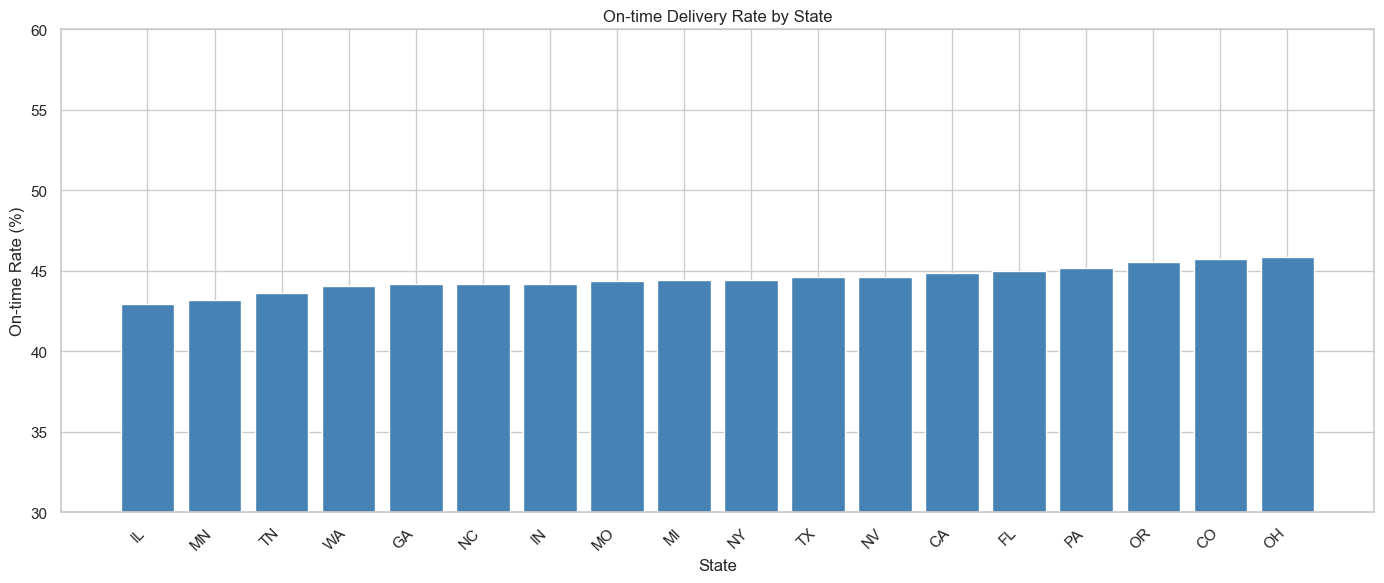

In [178]:
state_ontime = (delivery_events[delivery_events['event_type'] == 'Delivery']
    .groupby('location_state')['on_time_flag']
    .mean()
    .mul(100)
    .sort_values(ascending=True)
    .reset_index()
)

plt.figure(figsize=(14, 6))
plt.bar(state_ontime['location_state'], state_ontime['on_time_flag'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('On-time Delivery Rate by State')
plt.ylabel('On-time Rate (%)')
plt.xlabel('State')
plt.ylim(30, 60)
plt.tight_layout()
plt.show()


Illinois, Minnesota and Tennessee have the lowest on-time delivery rates.

In [179]:
print(delivery_events.groupby('on_time_flag')['detention_minutes'].mean())

on_time_flag
False   95.41
True    88.46
Name: detention_minutes, dtype: float64


In [181]:
merged = delivery_events.merge(loads, on='load_id')
merged.head(5)
merged[merged['event_type'] == 'Delivery'].groupby('route_id')['on_time_flag'].mean().sort_values().head(10).reset_index().merge(routes, on='route_id')


,route_id,on_time_flag,origin_city,origin_state,destination_city,destination_state,typical_distance_miles,base_rate_per_mile,fuel_surcharge_rate,typical_transit_days
0,RTE00029,0.42,Seattle,WA,Charlotte,NC,2623,2.47,0.34,4
1,RTE00009,0.42,Dallas,TX,Indianapolis,IN,878,1.95,0.17,1
2,RTE00028,0.42,Seattle,WA,Houston,TX,2172,1.89,0.26,3
3,RTE00018,0.43,Philadelphia,PA,Indianapolis,IN,670,2.07,0.28,1
4,RTE00002,0.43,Atlanta,GA,Miami,FL,697,2.08,0.22,1
5,RTE00017,0.43,Philadelphia,PA,Minneapolis,MN,1130,1.81,0.34,1
6,RTE00051,0.43,Memphis,TN,Los Angeles,CA,1840,1.85,0.25,3
7,RTE00001,0.43,Atlanta,GA,Chicago,IL,677,1.70,0.19,1
8,RTE00052,0.43,Memphis,TN,Minneapolis,MN,804,1.63,0.34,1
9,RTE00033,0.43,Portland,OR,Seattle,WA,167,2.42,0.24,1
